# CRC Mutation Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load data
clinical = pd.read_csv('../data/clinical.csv')
matrix = pd.read_csv('../data/mutation_matrix.csv', index_col=0)

print(f"Clinical data: {clinical.shape}")
print(f"Mutation matrix: {matrix.shape}")
print(f"\nClinical columns:\n{clinical.columns.tolist()}")

Clinical data: (594, 42)
Mutation matrix: (528, 20638)

Clinical columns:
['patientId', 'AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'BUFFA_HYPOXIA_SCORE', 'CANCER_TYPE_ACRONYM', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DFS_MONTHS', 'DFS_STATUS', 'DSS_MONTHS', 'DSS_STATUS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'GENETIC_ANCESTRY_LABEL', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'IN_PANCANPATHWAYS_FREEZE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'OS_MONTHS', 'OS_STATUS', 'OTHER_PATIENT_ID', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PFS_MONTHS', 'PFS_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'RAGNUM_HYPOXIA_SCORE', 'SAMPLE_COUNT', 'SEX', 'SUBTYPE', 'WEIGHT', 'WINTER_HYPOXIA_SCORE', 'AJCC_STAGING_EDITION']


In [2]:
# Check SUBTYPE distribution — this should contain MSI/MSS status
print("SUBTYPE value counts:")
print(clinical['SUBTYPE'].value_counts())
print()

# Check OS status format
print("OS_STATUS value counts:")
print(clinical['OS_STATUS'].value_counts())
print()

# Check tumor stage
print("AJCC Stage value counts:")
print(clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].value_counts())

SUBTYPE value counts:
SUBTYPE
COAD_CIN     226
READ_CIN     102
COAD_MSI      60
COAD_GS       49
READ_GS        9
COAD_POLE      6
READ_POLE      4
READ_MSI       3
Name: count, dtype: int64

OS_STATUS value counts:
OS_STATUS
0:LIVING      471
1:DECEASED    120
Name: count, dtype: int64

AJCC Stage value counts:
AJCC_PATHOLOGIC_TUMOR_STAGE
STAGE IIA     171
STAGE I       103
STAGE IIIB     80
STAGE IV       58
STAGE IIIC     54
STAGE II       35
STAGE IVA      26
STAGE III      22
STAGE IIIA     14
STAGE IIB      12
STAGE IIC       2
STAGE IVB       2
STAGE IA        1
Name: count, dtype: int64


In [3]:
# Simplify subtype — combine COAD/READ prefixes
clinical['subtype_simple'] = clinical['SUBTYPE'].str.replace('COAD_', '').str.replace('READ_', '')
print("Simplified subtypes:")
print(clinical['subtype_simple'].value_counts())

# Convert OS status to binary
clinical['os_event'] = clinical['OS_STATUS'].str.startswith('1').astype(int)

# Convert survival months to numeric
clinical['OS_MONTHS'] = pd.to_numeric(clinical['OS_MONTHS'], errors='coerce')
clinical['DFS_MONTHS'] = pd.to_numeric(clinical['DFS_MONTHS'], errors='coerce')

# Merge clinical with mutation matrix on patientId
# Mutation matrix index is sampleId — need to match to patientId
# TCGA sample IDs are patient ID + "-01" suffix
matrix_reset = matrix.copy()
matrix_reset.index = matrix_reset.index.str[:12]  # trim to patient ID format
matrix_reset.index.name = 'patientId'

# Merge
merged = clinical.merge(matrix_reset, on='patientId', how='inner')
print(f"\nMerged dataset: {merged.shape}")
print(f"Subtype distribution in merged:\n{merged['subtype_simple'].value_counts()}")

Simplified subtypes:
subtype_simple
CIN     328
MSI      63
GS       58
POLE     10
Name: count, dtype: int64

Merged dataset: (528, 20682)
Subtype distribution in merged:
subtype_simple
CIN     328
MSI      63
GS       58
POLE     10
Name: count, dtype: int64


In [6]:
from sklearn.metrics import adjusted_rand_score

# Extract just the mutation matrix columns (gene columns start after clinical columns)
clinical_cols = clinical.columns.tolist() + ['patientId']
gene_cols = [c for c in merged.columns if c not in clinical_cols and c != 'mutation_burden' and c != 'cluster']
print(f"Total genes: {len(gene_cols)}")
# Filter to genes mutated in at least 3% of patients (~16 patients)
min_samples = int(0.03 * len(merged))
gene_counts = merged[gene_cols].sum()
frequent_genes = gene_counts[gene_counts >= min_samples].index.tolist()
print(f"Genes mutated in ≥3% of patients: {len(frequent_genes)}")
# Build filtered mutation matrix
X = merged[frequent_genes].values
# Get true labels aligned to current merged index
labels_true = merged['subtype_simple'].fillna('Unknown').values
print(f"\nFiltered matrix shape: {X.shape}")
print(f"\nTop 20 most frequently mutated genes:")
print(gene_counts[frequent_genes].sort_values(ascending=False).head(20))

Total genes: 20638
Genes mutated in ≥3% of patients: 3412

Filtered matrix shape: (528, 3412)

Top 20 most frequently mutated genes:
APC       387
TP53      309
TTN       256
KRAS      217
PIK3CA    145
MUC16     145
SYNE1     144
FAT4      124
RYR2      105
OBSCN      98
ZFHX4      94
FLG        94
DNAH5      92
LRP1B      92
FBXW7      90
CSMD3      89
CSMD1      88
DNAH11     84
RYR1       82
FAT3       81
dtype: int64


In [7]:
# Keep top 100 most frequently mutated genes
top_genes = gene_counts[frequent_genes].sort_values(ascending=False).head(100).index.tolist()
X_top = merged[top_genes].values
print(f"Final matrix for clustering: {X_top.shape}")
print(f"\nTop 100 genes selected — most frequently mutated in CRC")

# Quick look at mutation burden per subtype
merged['mutation_burden'] = merged[frequent_genes].sum(axis=1)
print(f"\nMutation burden by subtype (mean mutations per patient):")
print(merged.groupby('subtype_simple')['mutation_burden'].mean().sort_values(ascending=False).round(1))

Final matrix for clustering: (528, 100)

Top 100 genes selected — most frequently mutated in CRC

Mutation burden by subtype (mean mutations per patient):
subtype_simple
POLE    1708.7
MSI      553.6
GS        58.4
CIN       56.0
Name: mutation_burden, dtype: float64


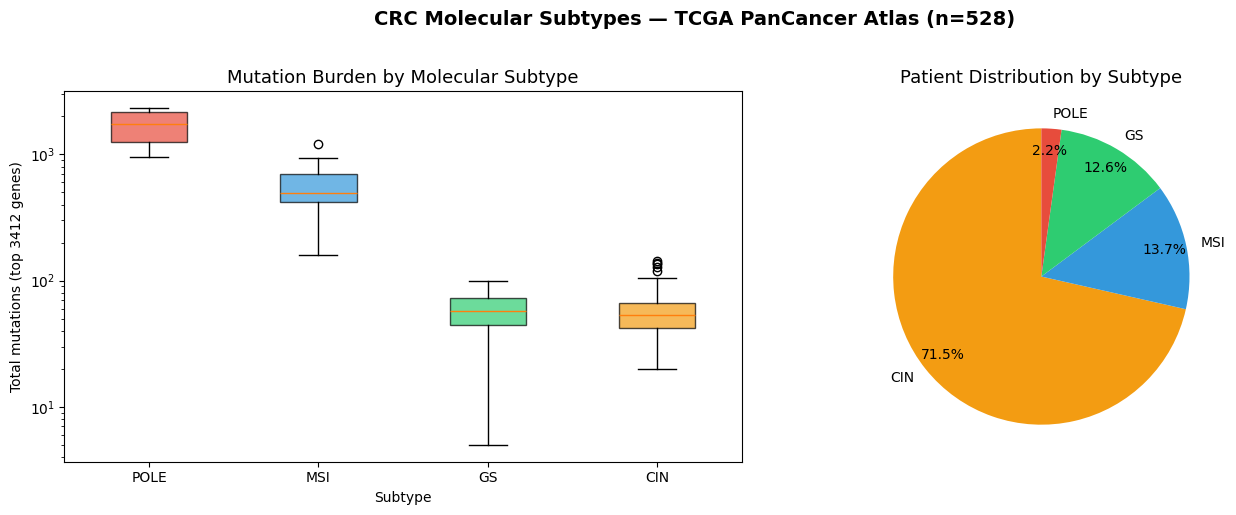

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mutation burden by subtype — boxplot
subtype_order = ['POLE', 'MSI', 'GS', 'CIN']
colors = {'POLE': '#e74c3c', 'MSI': '#3498db', 'GS': '#2ecc71', 'CIN': '#f39c12'}

data_to_plot = [merged[merged['subtype_simple'] == s]['mutation_burden'].values 
                for s in subtype_order]
bp = axes[0].boxplot(data_to_plot, labels=subtype_order, patch_artist=True)
for patch, s in zip(bp['boxes'], subtype_order):
    patch.set_facecolor(colors[s])
    patch.set_alpha(0.7)
axes[0].set_title('Mutation Burden by Molecular Subtype', fontsize=13)
axes[0].set_xlabel('Subtype')
axes[0].set_ylabel('Total mutations (top 3412 genes)')
axes[0].set_yscale('log')

# Subtype distribution pie chart
counts = merged['subtype_simple'].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[colors[s] for s in counts.index],
            startangle=90, pctdistance=0.85)
axes[1].set_title('Patient Distribution by Subtype', fontsize=13)

plt.suptitle('CRC Molecular Subtypes — TCGA PanCancer Atlas (n=528)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/subtype_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Scale the mutation matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# PCA — reduce to 50 components first, then visualize in 2D
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by top 10 PCs:")
for i, v in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"  PC{i+1}: {v:.3f} ({v*100:.1f}%)")
print(f"\nTotal variance explained by 50 PCs: {pca.explained_variance_ratio_.sum():.3f}")

# K-means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca)

# Evaluate
sil = silhouette_score(X_pca, cluster_labels)
ari = adjusted_rand_score(labels_true, cluster_labels)
print(f"\nClustering results:")
print(f"  Silhouette score: {sil:.3f}  (higher is better, max=1.0)")
print(f"  Adjusted Rand Index vs true subtypes: {ari:.3f}  (1.0 = perfect recovery)")

# How well do clusters map to known subtypes?
merged['cluster'] = cluster_labels
print(f"\nCluster vs subtype crosstab:")
print(pd.crosstab(merged['cluster'], merged['subtype_simple']))

Variance explained by top 10 PCs:
  PC1: 0.259 (25.9%)
  PC2: 0.019 (1.9%)
  PC3: 0.019 (1.9%)
  PC4: 0.018 (1.8%)
  PC5: 0.016 (1.6%)
  PC6: 0.016 (1.6%)
  PC7: 0.015 (1.5%)
  PC8: 0.015 (1.5%)
  PC9: 0.015 (1.5%)
  PC10: 0.014 (1.4%)

Total variance explained by 50 PCs: 0.795

Clustering results:
  Silhouette score: 0.410  (higher is better, max=1.0)
  Adjusted Rand Index vs true subtypes: 0.396  (1.0 = perfect recovery)

Cluster vs subtype crosstab:
subtype_simple  CIN  GS  MSI  POLE
cluster                           
0                 0   0   28     0
1               328  58    0     0
2                 0   0    4    10
3                 0   0   31     0


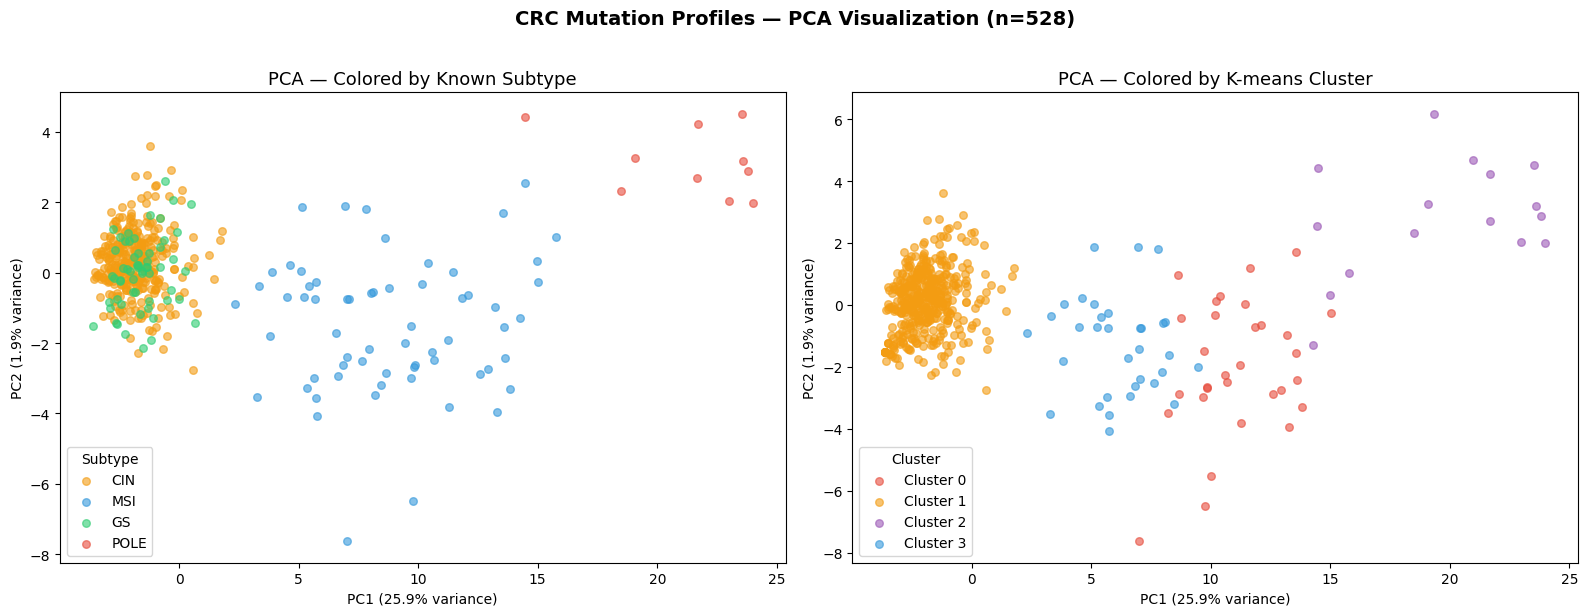

In [10]:
# Visualize clusters in 2D PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

subtype_colors = {'CIN': '#f39c12', 'MSI': '#3498db', 'GS': '#2ecc71', 'POLE': '#e74c3c'}
cluster_colors = {0: '#e74c3c', 1: '#f39c12', 2: '#9b59b6', 3: '#3498db'}

# Plot 1 — color by known subtype
for subtype, color in subtype_colors.items():
    mask = merged['subtype_simple'] == subtype
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=color, label=subtype, alpha=0.6, s=30)
axes[0].set_title('PCA — Colored by Known Subtype', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(title='Subtype')

# Plot 2 — color by cluster assignment
for cluster, color in cluster_colors.items():
    mask = merged['cluster'] == cluster
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, label=f'Cluster {cluster}', alpha=0.6, s=30)
axes[1].set_title('PCA — Colored by K-means Cluster', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(title='Cluster')

plt.suptitle('CRC Mutation Profiles — PCA Visualization (n=528)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

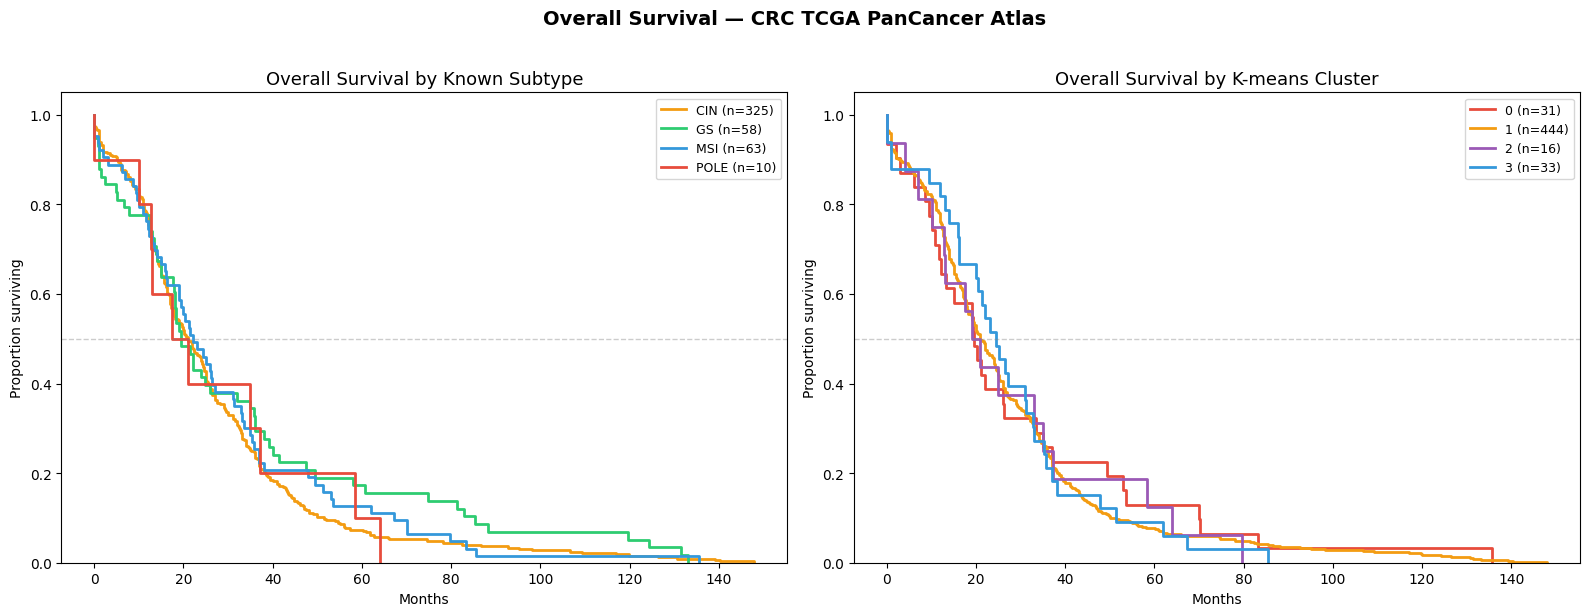

In [11]:
from matplotlib.lines import Line2D

# Convert OS months to numeric and create survival data
merged['OS_MONTHS'] = pd.to_numeric(merged['OS_MONTHS'], errors='coerce')
merged['os_event'] = merged['OS_STATUS'].str.startswith('1').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

subtype_colors = {'CIN': '#f39c12', 'MSI': '#3498db', 'GS': '#2ecc71', 'POLE': '#e74c3c'}
cluster_colors = {0: '#e74c3c', 1: '#f39c12', 2: '#9b59b6', 3: '#3498db'}

# Simple survival plot — % alive over time by subtype
for ax, groupby_col, colors, title in [
    (axes[0], 'subtype_simple', subtype_colors, 'Overall Survival by Known Subtype'),
    (axes[1], 'cluster', cluster_colors, 'Overall Survival by K-means Cluster')
]:
    groups = merged[groupby_col].unique()
    for group in sorted([g for g in groups if pd.notna(g)]):
        subset = merged[merged[groupby_col] == group].dropna(subset=['OS_MONTHS'])
        if len(subset) < 5:
            continue
        # Sort by time
        times = sorted(subset['OS_MONTHS'].values)
        n = len(times)
        # Simple Kaplan-Meier style step function
        survival = [1.0]
        for i, t in enumerate(times):
            survival.append(1 - (i + 1) / n)
        times_plot = [0] + times
        label = f"{group} (n={n})"
        color = colors.get(group, 'gray')
        ax.step(times_plot, survival, where='post', 
                color=color, label=label, linewidth=2)
    
    ax.set_xlabel('Months')
    ax.set_ylabel('Proportion surviving')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('Overall Survival — CRC TCGA PanCancer Atlas', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

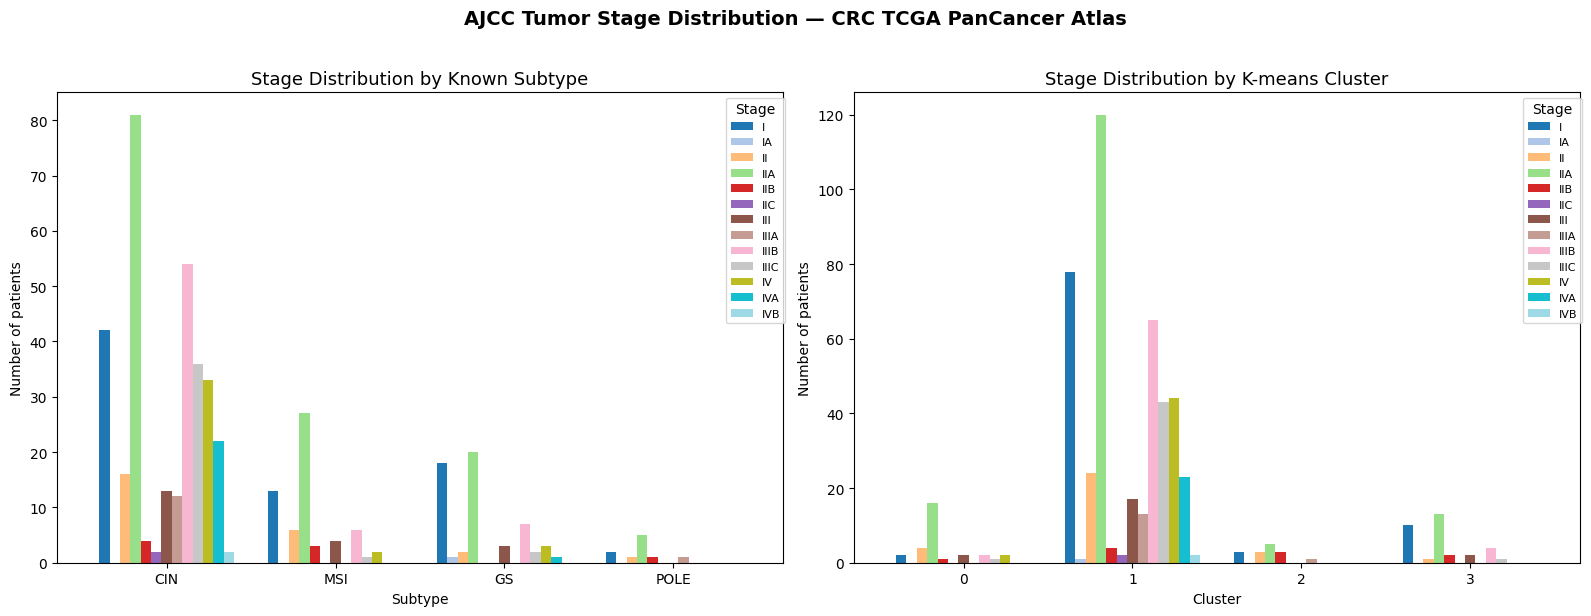

In [12]:
# Stage distribution by cluster and subtype
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clean up stage labels
merged['stage_clean'] = merged['AJCC_PATHOLOGIC_TUMOR_STAGE'].str.replace(
    'STAGE ', '').str.strip()

# Order stages
stage_order = ['I', 'IA', 'II', 'IIA', 'IIB', 'IIC', 'III', 'IIIA', 'IIIB', 
               'IIIC', 'IV', 'IVA', 'IVB']

# Plot 1 — stage distribution by known subtype
subtype_order = ['CIN', 'MSI', 'GS', 'POLE']
stage_by_subtype = merged.groupby(['subtype_simple', 'stage_clean']).size().unstack(fill_value=0)
stage_by_subtype = stage_by_subtype.reindex(index=subtype_order, 
                                             columns=[s for s in stage_order 
                                             if s in stage_by_subtype.columns])
stage_by_subtype.plot(kind='bar', ax=axes[0], colormap='tab20', width=0.8)
axes[0].set_title('Stage Distribution by Known Subtype', fontsize=13)
axes[0].set_xlabel('Subtype')
axes[0].set_ylabel('Number of patients')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Stage', bbox_to_anchor=(1.01, 1), fontsize=8)

# Plot 2 — stage distribution by cluster
stage_by_cluster = merged.groupby(['cluster', 'stage_clean']).size().unstack(fill_value=0)
stage_by_cluster = stage_by_cluster.reindex(columns=[s for s in stage_order 
                                            if s in stage_by_cluster.columns])
stage_by_cluster.plot(kind='bar', ax=axes[1], colormap='tab20', width=0.8)
axes[1].set_title('Stage Distribution by K-means Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of patients')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Stage', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.suptitle('AJCC Tumor Stage Distribution — CRC TCGA PanCancer Atlas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

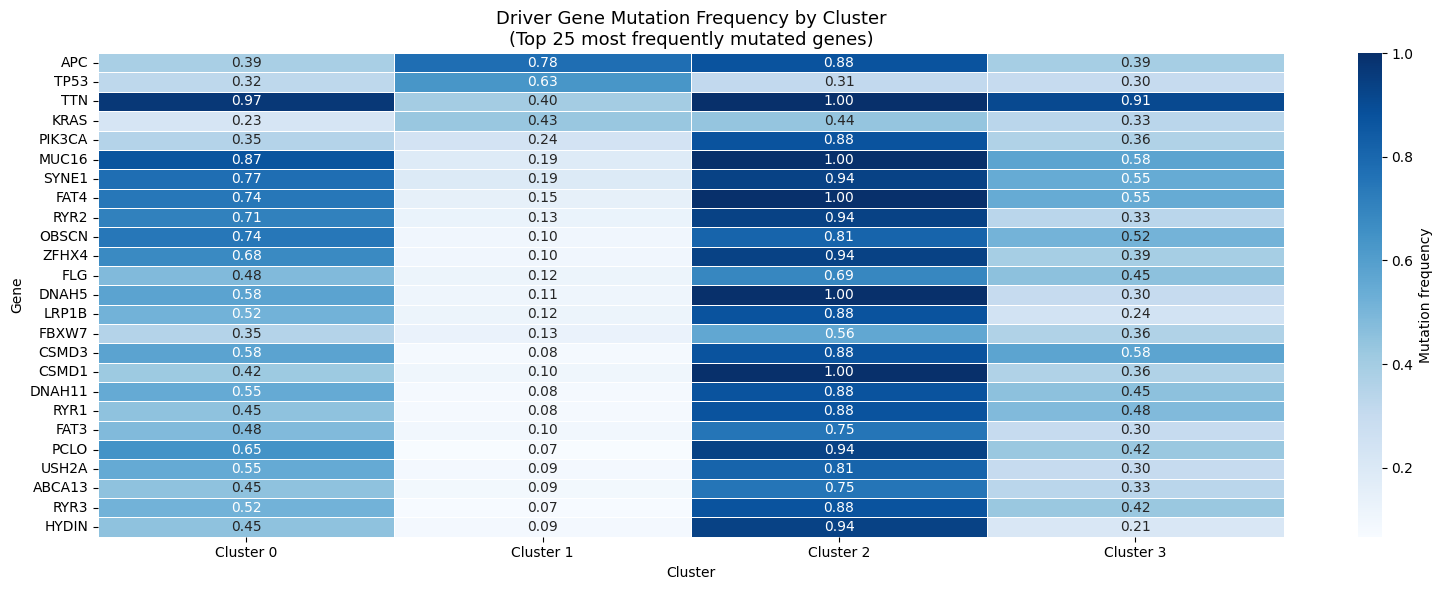

In [13]:
# Driver gene heatmap — mutation frequency per cluster for top genes
top_genes = gene_counts[frequent_genes].sort_values(ascending=False).head(25).index.tolist()

# Calculate mutation rate per cluster for each top gene
cluster_gene_rates = merged.groupby('cluster')[top_genes].mean()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(cluster_gene_rates.T, 
            annot=True, fmt='.2f', 
            cmap='Blues',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Mutation frequency'})

ax.set_title('Driver Gene Mutation Frequency by Cluster\n(Top 25 most frequently mutated genes)', 
             fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Gene')
ax.set_xticklabels([f'Cluster {c}' for c in cluster_gene_rates.index])

plt.tight_layout()
plt.savefig('../data/gene_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()